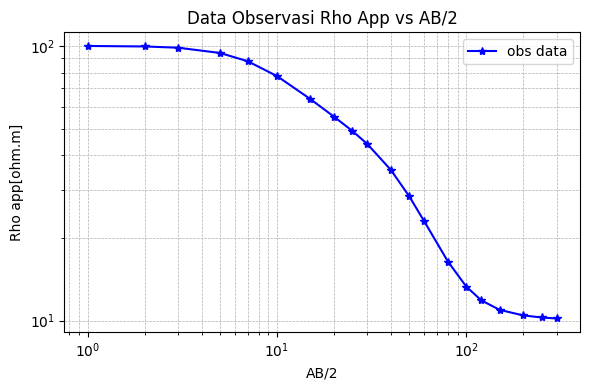

In [8]:
import numpy as np                          #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt             #import library matplotlib untuk memvisualisasikan grafik

data = np.loadtxt(r'D:\smt 6\prak inversi\minggu 7\Data_Obs_Tanpa_Noise.txt')   #membaca data yang di input
ab2 = data[:, 0]                            #menyimpan ke variabel ab2
rho_apparent = data[:, 1]                   #menyimpan semua baris pada kolom kedua ke rho app

plt.figure(figsize=(6, 4))                  #plot grafik size 6x4
plt.plot(ab2, rho_apparent, '*-', color='blue',label='obs data')    #plot grafik ab2 dan rho app dengan keterngan marker, warna dan label
plt.xscale('log')                           #plot sumbu x ke log
plt.yscale('log')                           #plot sumbu y ke log
plt.xlabel('AB/2')                          #plot sumbu x menjadi AB/2
plt.ylabel('Rho app[ohm.m]')                #plot sumbu y menjadi Rho app
plt.grid(True, which='both', linestyle='--', linewidth=0.5) #plot grid pada grafik
plt.legend()                                #plot legenda
plt.title('Data Observasi Rho App vs AB/2') #plot judul
plt.tight_layout()                          #plot layout 
plt.show()                                  #plot visualisasi grafik

In [ ]:
bounds = [(10, 200), (10, 200), (10, 200), (1, 50), (1, 50)]    #batas minimum dan maksimum parameter model (3 resistivitas, 2 ketebalan)
num_particles = 100                                             #jumlah partikel dalam PSO
dimensions = 5                                                  #jumlah parameter yang dicari (3 rho + 2 thickness)
iterations = 100                                                #jumlah iterasi PSO
c1 = 1.5                                                        #koefisien pengaruh personal best
c2 = 1.5                                                        #koefisien pengaruh global best

def fungsi_objektif(rhoap_obs, rhoap_cal):                      #fungsi untuk menghitung error antara data observasi dan kalkulasi
    return np.sqrt(np.mean((rhoap_obs - rhoap_cal) ** (2)))     #menghitung nilai RMSE

def filter_coefficent(filter_coeff):                            #fungsi memilih koefisien filter digital
    if filter_coeff == 'guptasarma_7':                          #jika memakai filter guptasarma 7 titik
        a = np.array([-0.17445, 0.09672, 0.36789, 0.63906, 0.91023, 1.1814, 1.45257])   #nilai koefisien a
        phi = np.array([0.1732, 0.2945, 2.147, -2.1733, 0.6646, -0.1215, 0.0155])       #nilai koefisien phi

    elif filter_coeff == 'guptasarma_11':                       #jika memakai filter guptasarma 11 titik
        a = np.array([-0.420625, -0.20265625, 0.0153125, 0.23328125, 0.45125, 0.66921875, 0.8871875, 1.10515625, 1.323125, 1.54109375, 1.7590625])
        phi = np.array([0.041873, -0.022258, 0.38766, 0.647103, 1.84873, - 2.96084, 1.358412, -0.37759, 0.097107, -0.024243, 0.004046])

    elif filter_coeff == 'guptasarma_22':                       #jika memakai filter guptasarma 22 titik
        a = np.array([-0.980685, -0.771995, -0.563305, -0.354615, -0.145925, 0.062765, 0.271455, 0.480145,  0.688835,  0.897525,  1.106215, 1.314905, 1.523595, 1.732285, 1.940975, 2.149665,  2.358355,  2.567045, 2.775735])
        phi = np.array([0.00097112, -0.00102152, 0.00906965, 0.01404316, 0.09012,  0.30171582, 0.99627084, 1.3690832, -2.99681171, 1.65463068, -0.59399277,  0.22329813 , -0.10119309,  0.05186135, -0.02748647, 0.01384932, -0.00599074, 0.00190463, -0.0003216 ])
    return a, phi                                               #mengembalikan nilai a dan phi

def forward(ab2, rhotr, thick, a, phi):                         #fungsi forward modelling geolistrik 1D
    rhoap_cal = []                                              #list kosong untuk menyimpan rho apparent hasil perhitungan
    for L in ab2:                                               #looping tiap jarak AB/2
        layer = len(rhotr) - 1                                  #menentukan jumlah layer terakhir
        T = rhotr[-1]                                           #nilai resistivitas layer paling bawah
        T_phi = []                                              #list kosong hasil perkalian T dan phi

        for i in range(len(a)):                                 #looping setiap koefisien filter
            lambda_r = 10 ** (a[i] - np.log10(L))               #menghitung lambda
            temp_layer = layer                                  #menyimpan layer sementara
            temp_T = T                                          #menyimpan T sementara

            while temp_layer > 0:                               #perulangan dari bawah ke atas layer
                temp_layer -= 1                                 #naik satu layer
                val = lambda_r * thick[temp_layer]              #menghitung lambda x ketebalan
                val = np.clip(val, -50, 50)                     #membatasi nilai agar stabil
                tanh = np.tanh(val)                             #menghitung tanh
                tanh = np.tanh(lambda_r * thick[temp_layer])    #menghitung ulang tanh
                temp_T = (temp_T + rhotr[temp_layer] * tanh) / (1 + temp_T * tanh / rhotr[temp_layer]) #rekurensi resistivitas

            T_phi.append(temp_T * phi[i])                       #menyimpan hasil kali T dan phi

        rho_app = np.sum(T_phi)                                 #menjumlahkan seluruh kontribusi filter
        rhoap_cal.append(rho_app)                               #menyimpan rho apparent

    return np.array(rhoap_cal)                                  #mengembalikan rho apparent kalkulasi

def pso(bounds, num_particles, dimensions, ab2, rhoap_obs, iterations, c1=1.5, c2=1.5):   #fungsi utama PSO
    particles = []                                              #menyimpan posisi partikel
    velocities = []                                             #menyimpan kecepatan partikel
    pbest_positions = []                                        #menyimpan posisi terbaik tiap partikel
    pbest_scores = []                                           #menyimpan nilai error terbaik tiap partikel
    gbest_score = float('inf')                                  #nilai error global terbaik awal
    gbest_position = []                                         #posisi global terbaik
    erms = []                                                   #menyimpan error tiap iterasi

    a, phi = filter_coefficent('guptasarma_7')                  #memilih filter guptasarma 7

    for _ in range(num_particles):                              #membuat populasi awal partikel
        position = [np.random.uniform(bounds[d][0], bounds[d][1]) for d in range(dimensions)] #posisi acak awal
        velocity = np.zeros(dimensions)                         #kecepatan awal nol

        rhotr = position[:3]                                    #3 parameter pertama = resistivitas
        thick = position[3:]                                    #2 parameter terakhir = ketebalan
        rhoap_cal = forward(ab2, rhotr, thick, a, phi)          #forward modelling
        score = fungsi_objektif(rhoap_obs, rhoap_cal)           #hitung error

        particles.append(position)                              #simpan posisi partikel
        velocities.append(velocity)                             #simpan kecepatan
        pbest_positions.append(position[:])                     #simpan posisi terbaik awal
        pbest_scores.append(score)                              #simpan score terbaik awal

        if score < gbest_score:                                 #jika lebih baik dari global best
            gbest_score = score                                 #update global score
            gbest_position = position[:]                        #update global posisi

    for _ in range(iterations):                                 #looping iterasi utama
        for i in range(num_particles):                          #evaluasi semua partikel
            rhotr = particles[i][:3]                            #ambil resistivitas
            thick = particles[i][3:]                            #ambil ketebalan
            rhoap_cal = forward(ab2, rhotr, thick, a, phi)      #forward modelling
            score = fungsi_objektif(rhoap_obs, rhoap_cal)       #hitung error

            if score < pbest_scores[i]:                         #jika lebih baik dari personal best
                pbest_scores[i] = score                         #update score terbaik
                pbest_positions[i] = particles[i][:]            #update posisi terbaik

            if score < gbest_score:                             #jika lebih baik dari global best
                gbest_score = score                             #update global score
                gbest_position = particles[i][:]                #update global posisi

        for i in range(num_particles):                          #update kecepatan dan posisi
            for d in range(dimensions):                         #loop tiap dimensi parameter
                r1 = np.random.random()                         #bilangan acak 0-1
                r2 = np.random.random()                         #bilangan acak 0-1
                velocities[i][d] = (velocities[i][d] + c1 * r1 * (pbest_positions[i][d] - particles[i][d]) + c2 * r2 * (gbest_position[d] - particles[i][d])) #rumus update velocity
                particles[i][d] += velocities[i][d]             #update posisi
                particles[i][d] = max(bounds[d][0], min(bounds[d][1], particles[i][d])) #membatasi posisi sesuai bounds

        erms.append(gbest_score)                                #menyimpan error terbaik tiap iterasi

    return gbest_position, gbest_score, erms                    #mengembalikan model terbaik, misfit, dan error history

best_model, best_misfit, erms_results = pso(bounds, num_particles, dimensions, ab2, rho_apparent, iterations=100) #menjalankan PSO

print("Model terbaik:", best_model)                             #menampilkan model parameter terbaik
print("Misfit terbaik:", best_misfit)                           #menampilkan error terkecil
print(best_model[:3])                                           #menampilkan resistivitas layer
print(best_model[3:])                                           #menampilkan ketebalan layer
print(erms_results)                                             #menampilkan riwayat error tiap iterasi

Model terbaik: [97.58658531006644, 43.78992283689958, 10, 5.775848649671517, 22.032779618088313]
Misfit terbaik: 1.1911616869680424
[97.58658531006644, 43.78992283689958, 10]
[5.775848649671517, 22.032779618088313]
[12.976105212057076, 5.212541532454443, 5.055173644968391, 5.055173644968391, 5.055173644968391, 4.639121652904344, 4.478351996122705, 4.478351996122705, 3.0990093460843036, 3.0990093460843036, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.994188450939227, 2.8607715430334166, 2.8607715430334166, 2.8607715430334166, 2.8607715430334166, 2.8607715430334166, 2.7330624020837377, 2.7330624020837377, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1.1911616869680424, 1

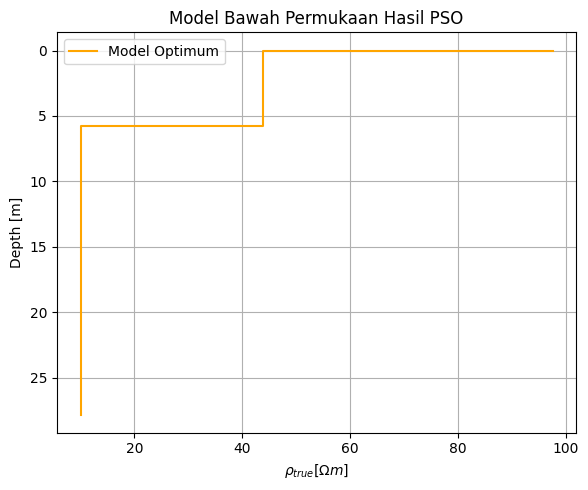

In [ ]:
import matplotlib.pyplot as plt                        #import library matplotlib untuk memvisualisasikan grafik

rho_best = best_model[:3]                              #mengambil 3 parameter pertama dari model terbaik sebagai resistivitas layer
thick_best = best_model[3:]                            #mengambil parameter sisanya sebagai ketebalan layer

depth = [0]                                            #membuat list kedalaman awal dimulai dari 0 meter
for t in thick_best:                                   #looping setiap nilai ketebalan
    depth.append(depth[-1] + t)                        #menjumlahkan ketebalan sebelumnya untuk mendapatkan kedalaman kumulatif
depth.append(depth[-1])                                #menambahkan kedalaman terakhir agar grafik step tertutup

rho_plot = list(rho_best) + [rho_best[-1]]             #menambahkan nilai resistivitas terakhir agar jumlah data sesuai grafik step

plt.figure(figsize=(6, 5))                             #membuat ukuran grafik 6x5
plt.step(rho_plot, depth, where='post', label='Model Optimum', color='orange')  #memplot model berlapis dengan grafik tangga(step)

plt.gca().invert_yaxis()                               #membalik sumbu y agar kedalaman bertambah ke bawah

plt.xlabel(r'$\rho_{true}[\Omega m]$')                 #memberi nama sumbu x resistivitas
plt.ylabel('Depth [m]')                                #memberi nama sumbu y kedalaman
plt.title('Model Bawah Permukaan Hasil PSO')           #memberi judul grafik
plt.grid(True)                                         #menampilkan grid
plt.legend()                                           #menampilkan legenda
plt.tight_layout()                                     #mengatur layout agar rapi
plt.show()                                             #menampilkan grafik

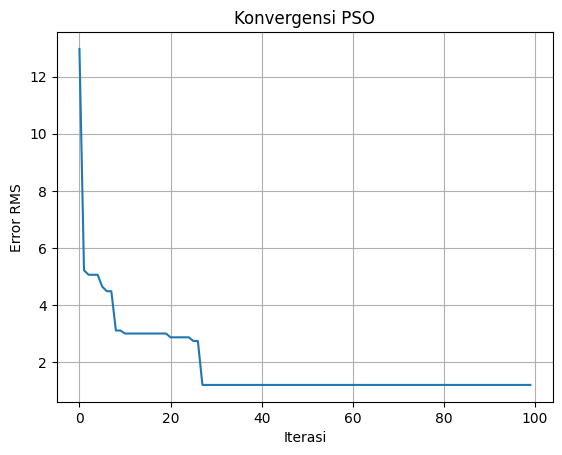

In [16]:
plt.plot(erms_results)                #memplot nilai error RMS dari setiap iterasi
plt.xlabel("Iterasi")                 #memberi nama sumbu x sebagai iterasi
plt.ylabel("Error RMS")               #memberi nama sumbu y sebagai error RMS
plt.title("Konvergensi PSO")          #memberi judul grafik konvergensi PSO
plt.grid(True)                        #menampilkan grid pada grafik
plt.show()                            #menampilkan grafik